# The Conditional Term Structure of Risk Premia

This notebook demonstrates the **conditional** version of the model from ["Macro Strikes Back: The Term Structure of Risk Premia"](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4752696) (Bryzgalova, Huang, and Julliard, 2024).

The conditional model adds a *restricted* VAR(`q`) layer where the latent factors $v_t$ load only on lagged external predictors $z_{t-1}, \ldots, z_{t-q}$ (not on lagged $v$). The macro factor $g_t$ loads on the VAR innovations $\varepsilon_{v,t}$ and lags thereof, and the term structure of risk premia $\lambda^S_{g,t}$ becomes time-varying, indexed by both horizon $S$ and conditioning time $t$.

We use the authors' replication dataset: 275 FF portfolios, real GDP growth as the macro factor, and four external predictors (`pe_ratio`, `term_spread`, `default_spread`, `value_spread`).

In [1]:
from empfin import ConditionalRiskPremiaTermStructure, msb_conditional_replication
import matplotlib.pyplot as plt
import numpy as np

data_df, predictors = msb_conditional_replication()
gdp = data_df.pop("GDP")

Estimation runs automatically when the class is instantiated. With 2000 draws plus 2000 burn-in iterations, expect a runtime of a few minutes on the FF275 + GDP sample. `predictors` is required: the restricted VAR has latent factors load only on lagged predictors.

In [2]:
crpts = ConditionalRiskPremiaTermStructure(
    assets=data_df,
    factor=gdp,
    s_bar=12,
    predictors=predictors,
    n_draws=2000,
    burnin=2000,
    k=5,
    q=1,
)

100%|██████████| 4000/4000 [01:52<00:00, 35.61it/s]


To visialize the time-varying term structure of risk premia, we can replicate the chart from the original paper.

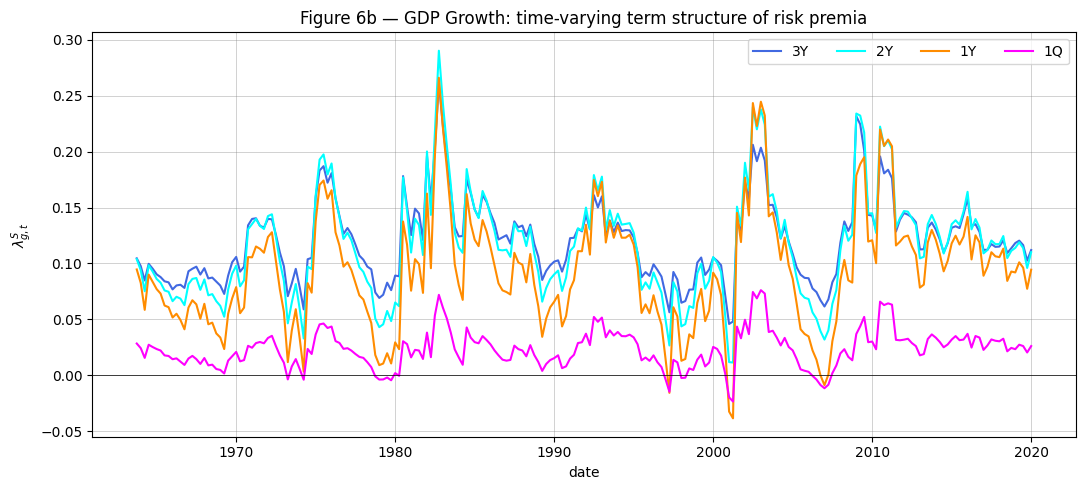

In [3]:
lambda_mean = crpts.draws_lambda_g.mean(axis=0)
dates = crpts.lambda_g_dates

# 1Q, 1Y, 2Y, 3Y on quarterly data correspond to S = 0, 4, 8, 12.
horizons = [(12, "3Y", "royalblue"),
            (8, "2Y", "cyan"),
            (4, "1Y", "darkorange"),
            (0, "1Q", "magenta"),]

fig, ax = plt.subplots(figsize=(5 * 16 / 7.3, 5))

for S, label, color in horizons:
    ax.plot(dates, lambda_mean[:, S], color=color, lw=1.5, label=label)

ax.axhline(0, color="black", lw=0.5)
ax.set(xlabel="date", ylabel=r"$\lambda^{S}_{g,t}$",
       title="Figure 6b — GDP Growth: time-varying term structure of risk premia")
ax.xaxis.grid(color="grey", ls="-", lw=0.5, alpha=0.5)
ax.yaxis.grid(color="grey", ls="-", lw=0.5, alpha=0.5)
ax.legend(frameon=True, loc="best", ncol=4)
plt.tight_layout()
plt.show()

The `plot_premia_time_series` method plots the time-varying risk premium for selected horizons in separate subplots. Each subplot shows the posterior median of $\lambda^S_{g,t}$ over time with a credible interval.

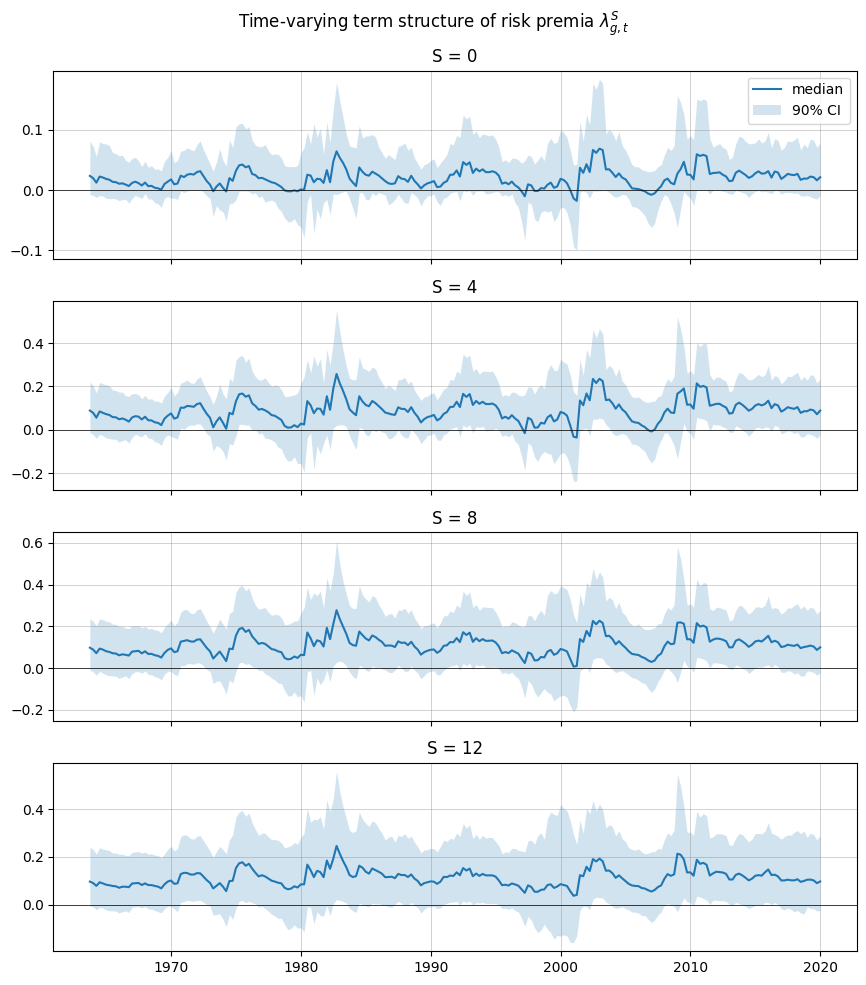

In [4]:
crpts.plot_premia_time_series(horizons=(0, 4, 8, 12))

We can also inspect the term structure of risk premia at a specific conditioning date. By default `plot_premia_term_structure` uses the latest available date.

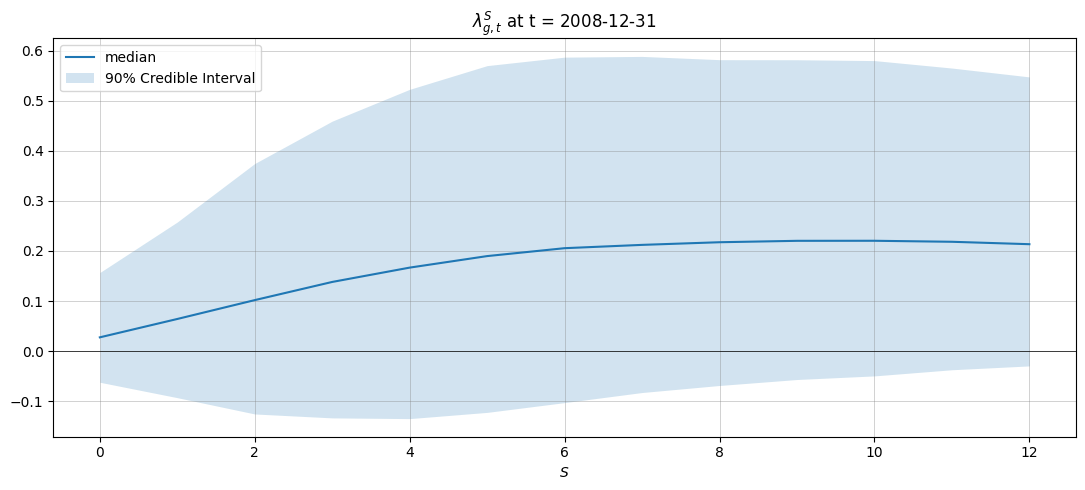

In [5]:
crpts.plot_premia_term_structure(t="2008-12-31")

Median factor loadings. Assets along the rows and latent factors along the columns.

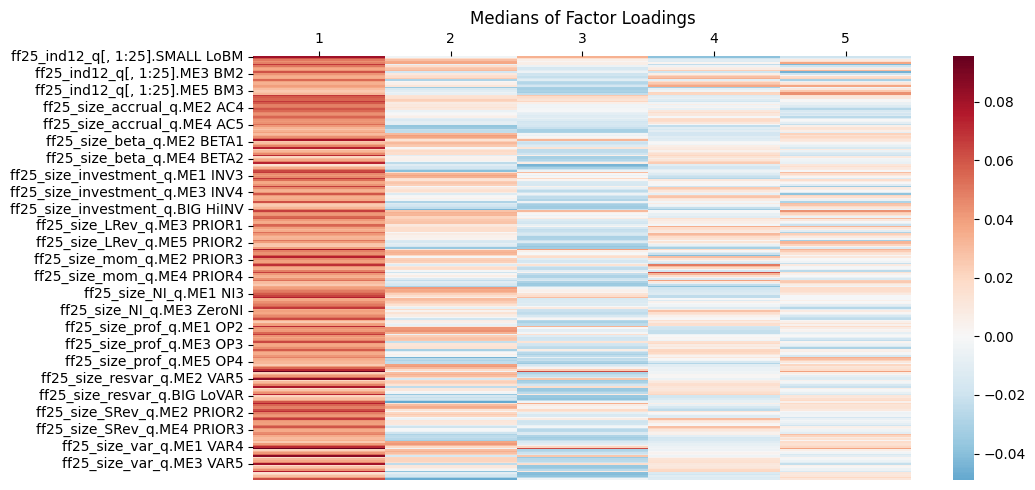

In [6]:
crpts.plot_loadings_heatmap()